## Behavioral Analysis Magnitude-Comparison task

prep data in `numrisk/prepare` (careful - onsets not aligned with scanner; handles the scanner-sync bug (almost every frame logged as event))

- take 1,all or 2-3 sessions ?


1. Raw Data
2. Cognitive Modellling: in `dyscalculia_ddm`repo (mrenke fork from ruffgroup) on sciencecloud (bauer v4, choice & rdm) - 



In [62]:
import pandas as pd
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
alpha = 0.05

bids_folder = '/Users/mrenke/data/ds-smile'
bids_folder_trace = '/Volumes/G_ADABD_Largefiles$/Data/DNumRisk_Data/ds-smile'

phenotype_folder = op.join(bids_folder, 'derivatives/phenotype')
plot_folder = op.join(bids_folder, 'results',  'plots')
stats_folder = op.join(bids_folder, 'results', 'stats')

[os.makedirs(folder, exist_ok=True) for folder in [plot_folder, stats_folder, phenotype_folder]]
sns.set_context('talk')


In [63]:
session = 'ses1' # 'allses' #'
df = pd.read_csv(op.join(bids_folder, f'magjudge_behavior_SMILE-{session}.csv')).set_index(['subject', 'group'])
groupList  = df.index.to_frame().drop_duplicates().reset_index(drop=True).set_index('subject')


Text(0.5, 1.08, 'SMILE - MagJudge Behavior: ses-1')

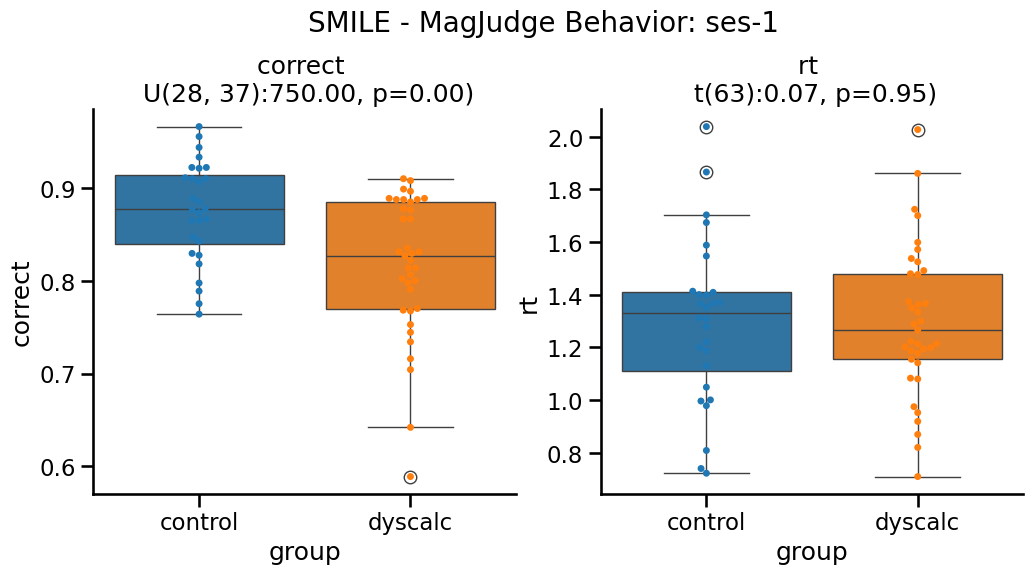

In [66]:
from parietal_patterns.utils.statistics import between_group_comparison


tmp = df.groupby('subject')[['correct', 'rt']].mean().join(groupList).sort_values('group')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for i, var in enumerate(['correct', 'rt']):
        stats, stats_term = between_group_comparison(tmp, var, alpha=0.05, group_names = ['control','dyscalc'])
        sns.boxplot(data=tmp.reset_index(), x='group', hue='group', y=var, ax=axs[i])
        sns.swarmplot(data=tmp.reset_index(), x='group', hue='group', y=var, ax=axs[i])
        axs[i].set_title(f'{var} \n {stats_term}:{stats.statistic:.2f}, p={stats.pvalue:.2f})')

sns.despine()
fig.suptitle(f'SMILE - MagJudge Behavior: {session}', fontsize=20, y=1.08)

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_55838/3986961658.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.catplot(data=tmp.reset_index(), x='n1', y='chose_n2', hue='group', kind='point',


Text(0.5, 1.0, 'SMILE - MagJudge Behavior: ses23')

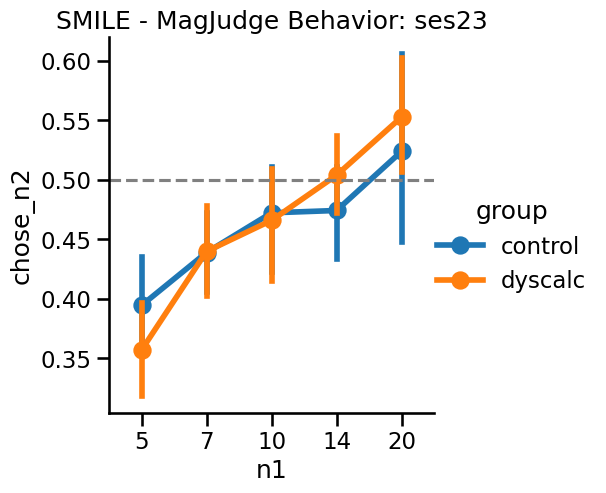

In [59]:
tmp = df.groupby(['subject', 'n1'])[['chose_n2']].mean().join(groupList).sort_values('group')
sns.catplot(data=tmp.reset_index(), x='n1', y='chose_n2', hue='group', kind='point',
            ci=95,height=5, aspect=1)
plt.axhline(0.5, ls='--', color='grey')
plt.title(f'SMILE - MagJudge Behavior: {session}')

## Cogmodel

In [64]:
# bauer model 
import arviz as az
from bauer.utils.bayes import softplus

model_label =  'rdm_full_cont' # 'choice_pm' #'
session = 'ses-1' # 'allses' #'

target_folder = op.join(bids_folder_trace, f'derivatives/cogmodels_magjudge')
traces =  az.from_netcdf(op.join(target_folder, f'model-{model_label}_hn_{session}_trace.nc'))

if 'choice' in model_label:
    parameters = ['perceptual_noise_sd', 'memory_noise_sd'] 
elif 'rdm' in model_label:
    parameters = ['perceptual_noise_sd', 'memory_noise_sd', 'a'] 



/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_55838/4158762883.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_new = pd.concat([df_new, pd.DataFrame(row,  index=[0])], ignore_index=True)


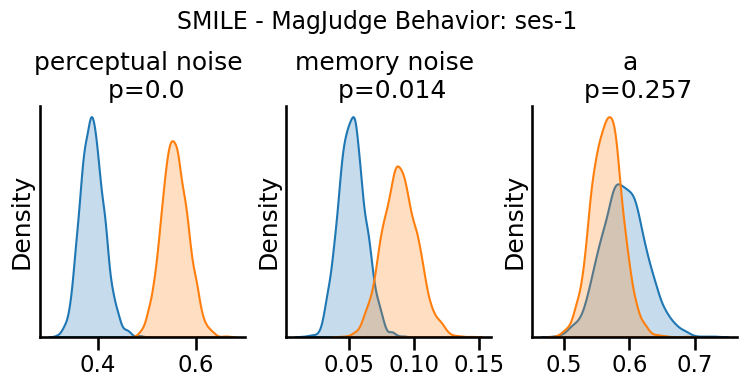

In [65]:
from bauer.utils.bayes import softplus

def round_CI(array):
    CI = np.percentile(array, [2.5, 97.5])
    CI = [np.round(i,3) for i in CI]
    return CI

N_params = len(parameters)
cols = ['model', 'param', 'effect', 'mean', 'CI_low','CI_high', 'p_0']

fig, axs = plt.subplots(1,N_params, figsize=(3*N_params,3))
df_new = pd.DataFrame(columns=cols)

for i, param in enumerate(parameters):
    tmp = traces.posterior[f'{param}_mu'].to_dataframe()[f'{param}_mu'].unstack(f'{param}_regressors')
    control = softplus(tmp['C(group)[control]'])
    dyscalc = softplus(tmp['C(group)[dyscalc]'])
    diff = dyscalc - control

    count_diff_from_zero = np.round(np.mean((diff) < 0),3)
    count_p_val = count_diff_from_zero if count_diff_from_zero < 0.5 else np.round(1-count_diff_from_zero, 3)

    sns.kdeplot(control, color=sns.color_palette()[0], fill=True, label='Control',legend=False, ax=axs[i])
    sns.kdeplot(dyscalc,  color=sns.color_palette()[1], fill=True, label='Dyscalculic', ax=axs[i])
    #plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') if noise== 'memory' else None
    axs[i].set(xlabel=None, yticks=[])
    param_name = (param.split('_')[0] + ' noise') if ('noise' in param) else param
    axs[i].set_title(f'{param_name} \n p={count_p_val}')
    sns.despine()

    for effect_name, posterior_samples in zip (['control', 'dyscalc', 'diff'], [control, dyscalc, diff]):
        count_diff_from_zero = np.round(np.mean((posterior_samples) < 0),3)
        count_p_val = count_diff_from_zero if count_diff_from_zero < 0.5 else np.round(1-count_diff_from_zero, 3)
        row = {'model':model_label, 
               'param':param,
               'effect': effect_name, 
               'mean': np.round(np.mean(posterior_samples),3), 
               'CI_low': round_CI(posterior_samples)[0],
                'CI_high': round_CI(posterior_samples)[1],
                'p_0': count_p_val}
        df_new = pd.concat([df_new, pd.DataFrame(row,  index=[0])], ignore_index=True)
        
    #print(f'{param}  difference: p={count_p_val}, mean dif={np.mean(diff):3f}, 95%CI={round_CI(diff)}')
    #print(f'control mean {param} : {np.round(np.mean(control),3)}, 95%CI={round_CI(control)}')   
    #print(f'dyscalc mean {param} : {np.round(np.mean(dyscalc),3)}, 95%CI={round_CI(dyscalc)}')   

fig.suptitle(f'SMILE - MagJudge Behavior: {session}', fontsize=17, y=1.2)
plt.savefig(op.join(plot_folder, f'mag_bauerv4_{model_label}_control-dys.pdf'), bbox_inches='tight')
df_new.to_csv(op.join(stats_folder, f'mag_bauerv4_{model_label}_posterior_params.csv'), index=False)